In [1]:
import numpy as np
import matplotlib.pyplot as plt
from utils import *
from cvx.sdp import *

In [2]:
pred_grad_f_list = []
pred_grad_ts_f_list = []
cor_grad_f_list = []
s_hat_list = []
theta_hat_list = []
f_list = []

In [17]:

def predict(s_hat, Theta_hat, Theta_hat_prev, alpha, h, D):
    s = s_hat.copy()
    S_inv = np.linalg.inv(vech_to_mat(s_hat))
    grad_f = D.T @ mat_to_vec(Theta_hat - S_inv)
    pred_grad_f_list.append(grad_f)
    grad_ts_f = D.T @ mat_to_vec(Theta_hat - Theta_hat_prev)
    pred_grad_ts_f_list.append(grad_ts_f)
    s -= 2 * alpha * (grad_f + h * grad_ts_f)
    return project(s)

def correct(s_hat, Theta_hat, beta, D):
    s = s_hat.copy()
    S_inv = np.linalg.inv(vech_to_mat(s_hat))
    grad_f = D.T @ mat_to_vec(Theta_hat - S_inv)
    cor_grad_f_list.append(grad_f)
    s -= beta * grad_f
    return project(s)

def project(s):
    S = vech_to_mat(s)
    eigvals, eigvecs = np.linalg.eigh(S)
    eigvals = np.maximum(eigvals, 0)
    S = eigvecs @ np.diag(eigvals) @ eigvecs.T
    return mat_to_vech(S)

# def normalize_covariance(cov_matrix):
#     variances = np.diagonal(cov_matrix)
#     stddevs = np.sqrt(variances)
#     diagonal_inv = np.diag(1 / stddevs)
#     corr_matrix = diagonal_inv @ cov_matrix @ diagonal_inv
#     return corr_matrix

def online_graph_learning(data, P, C, alpha, beta, gamma, S_true):
    N = data.shape[1]
    s_hat = mat_to_vech(S_true[0])
    Theta_hat = np.linalg.inv(S_true[0])
    Theta_hat_prev = Theta_hat
    theta_hat_list.append(mat_to_vec(Theta_hat))
    nses = []
    D = duplication_matrix(N)

    for t in range(N, data.shape[0]):
        if (t - N) % (data.shape[0] // 10) == 0:
            print(f"Iteration {t}/{data.shape[0]}")
        
        for _ in range(P):
            s_hat = predict(s_hat, Theta_hat, Theta_hat_prev, alpha, 1, D)

        x_t = data[t, :]
        Theta_hat_prev = Theta_hat
        Theta_hat = gamma * Theta_hat_prev + (1 - gamma) * np.outer(x_t, x_t)
        theta_hat_list.append(mat_to_vec(Theta_hat))

        for _ in range(C):
            s_hat = correct(s_hat, Theta_hat, beta, D)

        S_hat = vech_to_mat(s_hat)
        s_hat_list.append(s_hat)

        if t < data.shape[0] // 2:
            nse = np.linalg.norm(S_hat - S_true[0], ord='fro') ** 2 / np.linalg.norm(S_true[0], ord='fro') ** 2
        else:
            nse = np.linalg.norm(S_hat - S_true[1], ord='fro') ** 2 / np.linalg.norm(S_true[1], ord='fro') ** 2
        
        nses.append(nse)
        
        f = -np.log(np.linalg.det(S_hat) + 1e-6) + np.trace(S_hat @ Theta_hat)
        f_list.append(f)

    return vech_to_mat(s_hat), nses, f_list

def generate_data(N, T, seed=42):
    np.random.seed(seed)
    X = np.random.rand(N, N)
    Theta_true = []
    S_true = []
    Theta_true.append(X @ X.T)
    S_true.append(np.linalg.inv(Theta_true[0]))
    S_true.append(double_half_elements(S_true[0].copy()))
    Theta_true.append(np.linalg.inv(S_true[1]))
    
    data = np.zeros((T, N))
    data[:T//2, :] = np.random.multivariate_normal(mean=np.zeros(N), cov=Theta_true[0], size=T//2)
    data[T//2:, :] = np.random.multivariate_normal(mean=np.zeros(N), cov=Theta_true[1], size=T-T//2)

    print(Theta_true)
    
    return data, S_true

def double_half_elements(matrix):
    matrix[0, 0] *= 1.01
    matrix[5, 1] *= 1.01
    matrix[1, 5] *= 1.01
    matrix[2, 3] *= 1.01
    matrix[3, 2] *= 1.01

    # n = matrix.shape[0]
    # count = (n * n) // 2  # 半分の要素数を計算
    # indices = np.triu_indices(n)  # 上三角行列のインデックスを取得
    # # ランダムにインデックスを選ぶ
    # selected_indices = np.random.choice(len(indices[0]), count, replace=False)
    # for idx in selected_indices:
    #     i, j = indices[0][idx], indices[1][idx]
    #     matrix[i, j] *= 1.1
    #     if i != j:  # 対称な位置の要素も選んで2倍にする
    #         matrix[j, i] *= 1.1
    return matrix



[array([[3.60336207, 2.66131965, 1.8346095 , 2.10736453, 2.15785084,
        2.99301253, 2.79887389, 1.60084431, 2.75765083, 2.30546575],
       [2.66131965, 2.38521859, 1.29582275, 1.32504272, 1.53079055,
        2.26569003, 1.97087291, 1.11070164, 2.1047328 , 2.10327447],
       [1.8346095 , 1.29582275, 2.09531246, 2.37412965, 1.78729178,
        2.46054314, 1.73337698, 2.10518361, 2.15321943, 1.68419122],
       [2.10736453, 1.32504272, 2.37412965, 3.65299463, 2.41031782,
        3.17428074, 1.99150314, 3.0875353 , 2.37509479, 2.1858878 ],
       [2.15785084, 1.53079055, 1.78729178, 2.41031782, 2.29474036,
        2.32800729, 1.65126257, 2.09657002, 1.91040459, 1.85011509],
       [2.99301253, 2.26569003, 2.46054314, 3.17428074, 2.32800729,
        4.58576152, 2.84740956, 2.86902711, 2.55672427, 2.96829646],
       [2.79887389, 1.97087291, 1.73337698, 1.99150314, 1.65126257,
        2.84740956, 3.05510562, 1.55294281, 2.21177457, 2.08033217],
       [1.60084431, 1.11070164, 2.105183

Iteration 2010/20000
Iteration 4010/20000
Iteration 6010/20000
Iteration 8010/20000
Iteration 10010/20000
Iteration 12010/20000
Iteration 14010/20000
Iteration 16010/20000
Iteration 18010/20000


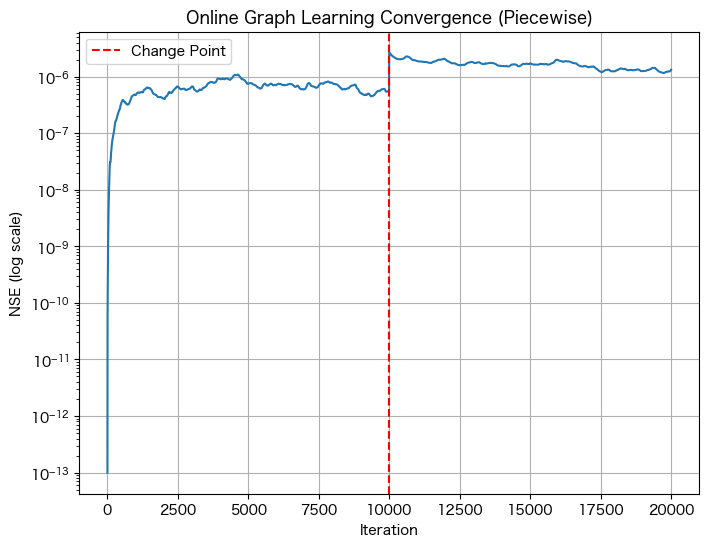

In [19]:
if __name__ == "__main__":

    N = 10
    T = 20000
    P = 1
    C = 1
    alpha = 0.0001
    beta = 0.0001
    gamma = 0.999
    
    data, S_true = generate_data(N, T)
    S_hat, nses, f_list = online_graph_learning(data, P, C, alpha, beta, gamma, S_true)
    
    plt.figure(figsize=(8, 6))
    plt.semilogy(nses)
    plt.axvline(T//2, color='red', linestyle='--', label='Change Point')
    plt.xlabel('Iteration')
    plt.ylabel('NSE (log scale)')
    plt.title('Online Graph Learning Convergence (Piecewise)')
    plt.grid(True)
    plt.legend()
    plt.show()

In [20]:
nses[10000:10100]

[2.629306504476054e-06,
 2.6282060250541396e-06,
 2.626944806926075e-06,
 2.625581910823728e-06,
 2.624477315415712e-06,
 2.6234421434477643e-06,
 2.6221684994166685e-06,
 2.6204851238670954e-06,
 2.6196833947618703e-06,
 2.618644378719018e-06,
 2.6178689272194412e-06,
 2.616822540711174e-06,
 2.615109274821787e-06,
 2.6135328140916336e-06,
 2.6111960370225493e-06,
 2.609844658334796e-06,
 2.6086059838040842e-06,
 2.6066140464039874e-06,
 2.6022357989400553e-06,
 2.5995335915867285e-06,
 2.5960660727847796e-06,
 2.5902069777234652e-06,
 2.583765017947858e-06,
 2.579339768806912e-06,
 2.575379586530864e-06,
 2.5715354962872143e-06,
 2.5679719826759687e-06,
 2.564216398558321e-06,
 2.5602678294977195e-06,
 2.5566684268038995e-06,
 2.553270273268937e-06,
 2.5497301188191915e-06,
 2.54595001730783e-06,
 2.5420622242049603e-06,
 2.5371091759069306e-06,
 2.5321413826267636e-06,
 2.5280540657116437e-06,
 2.5241712414246207e-06,
 2.52069132778361e-06,
 2.5170088613809044e-06,
 2.51253182575718

In [45]:
S_true[0]

array([[  53.57017162,   23.29130796,   28.46105677,  -16.8348222 ,
         -40.15098447,  -33.19959222,   -4.1253193 ,   68.67366072,
         -54.97704792,  -19.82453525],
       [  23.29130796,   82.82462047,   32.34594507,  -12.12430966,
         -45.69152918,  -39.23134585,   10.95022366,   97.92451511,
         -79.06775817,  -59.63275883],
       [  28.46105677,   32.34594507,   27.63698454,  -12.55927532,
         -30.41347893,  -26.28205423,    1.1353814 ,   55.04238431,
         -46.78351911,  -23.60515958],
       [ -16.8348222 ,  -12.12430966,  -12.55927532,   16.09901164,
          12.35901909,   11.83471036,   -1.28268228,  -33.39363374,
          22.78526091,   10.97253868],
       [ -40.15098447,  -45.69152918,  -30.41347893,   12.35901909,
          45.43516318,   35.43961757,   -2.0250048 ,  -77.79044609,
          62.55336685,   33.14963609],
       [ -33.19959222,  -39.23134585,  -26.28205423,   11.83471036,
          35.43961757,   35.1944381 ,   -3.8618862 ,  -67

In [44]:
np.linalg.inv(S_true[0])

array([[1.        , 0.90777663, 0.66767527, 0.58084626, 0.75041359,
        0.73628991, 0.84356056, 0.4809807 , 0.78804273, 0.73595132],
       [0.90777663, 1.        , 0.57963835, 0.44889138, 0.65431203,
        0.68506325, 0.73009843, 0.41017182, 0.73926019, 0.82523231],
       [0.66767527, 0.57963835, 1.        , 0.85813481, 0.81508759,
        0.79378128, 0.68510244, 0.82946504, 0.80691602, 0.70503612],
       [0.58084626, 0.44889138, 0.85813481, 1.        , 0.83249765,
        0.77555943, 0.59613327, 0.92133998, 0.67409464, 0.6930231 ],
       [0.75041359, 0.65431203, 0.81508759, 0.83249765, 1.        ,
        0.71764857, 0.62364327, 0.78935996, 0.6841054 , 0.74007602],
       [0.73628991, 0.68506325, 0.79378128, 0.77555943, 0.71764857,
        1.        , 0.76073096, 0.76411974, 0.64765333, 0.83993544],
       [0.84356056, 0.73009843, 0.68510244, 0.59613327, 0.62364327,
        0.76073096, 1.        , 0.50672794, 0.68642357, 0.72121364],
       [0.4809807 , 0.41017182, 0.8294650

In [10]:
np.linalg.inv(S_true[1])

array([[2.        , 0.90777663, 0.66767527, 0.58084626, 0.75041359,
        0.73628991, 0.84356056, 0.4809807 , 0.78804273, 0.73595132],
       [0.90777663, 1.        , 0.57963835, 0.44889138, 0.65431203,
        1.37012649, 0.73009843, 0.41017182, 0.73926019, 0.82523231],
       [0.66767527, 0.57963835, 1.        , 1.71626961, 0.81508759,
        0.79378128, 0.68510244, 0.82946504, 0.80691602, 0.70503612],
       [0.58084626, 0.44889138, 1.71626961, 1.        , 0.83249765,
        0.77555943, 0.59613327, 0.92133998, 0.67409464, 0.6930231 ],
       [0.75041359, 0.65431203, 0.81508759, 0.83249765, 1.        ,
        0.71764857, 0.62364327, 0.78935996, 0.6841054 , 0.74007602],
       [0.73628991, 1.37012649, 0.79378128, 0.77555943, 0.71764857,
        1.        , 0.76073096, 0.76411974, 0.64765333, 0.83993544],
       [0.84356056, 0.73009843, 0.68510244, 0.59613327, 0.62364327,
        0.76073096, 1.        , 0.50672794, 0.68642357, 0.72121364],
       [0.4809807 , 0.41017182, 0.8294650